In [1]:
import os
import pandas as pd
import numpy as np
from itertools import product
from math import log2



# Parse raw files and assign labels

In [2]:
# import pandas as pd
# import numpy as np
# from xgboost import XGBClassifier
# from sklearn.model_selection import train_test_split
# from sklearn.utils import resample
# from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# # Load CDBProm data
# df = pd.read_csv("./Datasets/CDB_prom.csv")
# X = df.drop(columns=['Unnamed: 0', 'label']).values.astype(np.float32)
# y = df['label'].values

# print(f"Dataset shape: {X.shape}")
# print(f"Class distribution: {np.bincount(y)}")

# # Train/test split
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )

# # Stage 1
# model1 = XGBClassifier(n_estimators=200, max_depth=7, learning_rate=0.1,
#                        subsample=0.8, eval_metric='logloss', random_state=42, n_jobs=-1)
# model1.fit(X_train, y_train)

# # Misclassifications
# y_train_pred = model1.predict(X_train)
# fp_idx = np.where((y_train_pred == 1) & (y_train == 0))[0]
# fn_idx = np.where((y_train_pred == 0) & (y_train == 1))[0]
# n_mis = min(len(fp_idx), len(fn_idx))
# fp_sample = resample(X_train[fp_idx], replace=False, n_samples=n_mis, random_state=42)
# fn_sample = resample(X_train[fn_idx], replace=False, n_samples=n_mis, random_state=42)
# X_mis = np.vstack([fp_sample, fn_sample])
# y_mis = np.array([0]*n_mis + [1]*n_mis)

# # Stage 2
# model2 = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
#                        eval_metric='logloss', random_state=42)
# model2.fit(X_mis, y_mis)

# # Predict
# def predict_two_stage(X, m1, m2):
#     p1 = m1.predict_proba(X)[:, 1]
#     use2 = p1 < 0.5
#     p = p1.copy()
#     if use2.any():
#         p[use2] = m2.predict_proba(X[use2])[:, 1]
#     return p

# y_proba = predict_two_stage(X_test, model1, model2)
# y_pred = (y_proba >= 0.5).astype(int)

# print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
# print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}")
# print(classification_report(y_test, y_pred))

In [34]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
tqdm.pandas()

# Re-parse raw bacteria files
data_dir = "Predictions_bacteria/"
all_data = []
for fname in os.listdir(data_dir):
    if fname.endswith("_upstream.txt"):
        fpath = os.path.join(data_dir, fname)
        with open(fpath, encoding="utf-8", errors="ignore") as f:
            for line in f:
                line = line.strip()
                if not line or line.startswith("Column"):
                    continue
                parts = line.split("\t")
                if len(parts) < 9:
                    continue
                try:
                    seq = parts[8].strip().upper()
                    if len(seq) == 60 and all(c in "ACGT" for c in seq):
                        all_data.append({"sequence": seq, "label": 1})
                except:
                    continue

df_pos = pd.DataFrame(all_data)
print(f"Positive sequences: {len(df_pos)}")

# Generate negatives via shuffling
rng = np.random.default_rng(42)
def shuffle_seq(seq):
    arr = list(seq)
    rng.shuffle(arr)
    return "".join(arr)

df_neg = df_pos.copy()
df_neg["sequence"] = df_neg["sequence"].apply(shuffle_seq)
df_neg["label"] = 0

df_full = pd.concat([df_pos, df_neg], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Total: {len(df_full)}, Balance: {df_full['label'].value_counts().to_dict()}")

# Extract named features
print("Extracting features...")
feature_dicts = df_full["sequence"].progress_apply(extract_features)
df_features = pd.DataFrame(list(feature_dicts))
df_features["label"] = df_full["label"].values

print(f"Feature matrix: {df_features.shape}")
print(f"Columns sample: {df_features.columns.tolist()[:6]}")

Positive sequences: 1796335
Total: 3592670, Balance: {0: 1796335, 1: 1796335}
Extracting features...


100%|███████████████████████████████| 3592670/3592670 [06:56<00:00, 8616.11it/s]


Feature matrix: (3592670, 102)
Columns sample: ['gc_content', 'at_content', 'entropy', 'seq_length', 'minus10_score', 'minus35_score']


In [35]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Prepare X and y
feature_cols = [c for c in df_features.columns if c != "label"]
X = df_features[feature_cols].values.astype(np.float32)
y = df_features["label"].values

print(f"Feature matrix: {X.shape}")
print(f"Class balance: {np.bincount(y)}")

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Stage 1
model = XGBClassifier(
    n_estimators=200, max_depth=7, learning_rate=0.1,
    subsample=0.8, eval_metric='logloss', random_state=42, n_jobs=-1
)
model.fit(X_train, y_train)

# Evaluate Stage 1
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("\n" + "="*50)
print("Stage 1 Results")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, y_proba):.4f}")
print(classification_report(y_test, y_pred, target_names=["Non-Promoter", "Promoter"]))

Feature matrix: (3592670, 101)
Class balance: [1796335 1796335]

Stage 1 Results
Accuracy: 0.7166
AUC-ROC:  0.7911
              precision    recall  f1-score   support

Non-Promoter       0.71      0.73      0.72    359267
    Promoter       0.72      0.70      0.71    359267

    accuracy                           0.72    718534
   macro avg       0.72      0.72      0.72    718534
weighted avg       0.72      0.72      0.72    718534



In [36]:
# Reload CDB_prom.csv raw sequences from the original CDBProm GitHub source
# This has real biological negatives (downstream regions)
import requests
from urllib3.exceptions import InsecureRequestWarning
requests.packages.urllib3.disable_warnings(category=InsecureRequestWarning)

url = "https://raw.githubusercontent.com/gustavsganzerla/cdbprom/main/training_data.csv"
df_cdb_raw = pd.read_csv(url)
print(df_cdb_raw.shape)
print(df_cdb_raw.head(3))
print(df_cdb_raw.columns.tolist())
print(df_cdb_raw['label'].value_counts())

(31259, 101)
   Unnamed: 0     0     1     2     3     4     5     6     7     8  ...  \
0           0 -1.44 -1.84 -2.27 -1.84 -1.45 -1.30 -1.84 -1.30 -1.45  ...   
1           1 -1.45 -1.45 -0.88 -1.00 -1.44 -2.27 -1.45 -1.45 -1.84  ...   
2           2 -1.84 -1.45 -0.88 -1.44 -1.84 -1.44 -1.00 -1.44 -2.27  ...   

     90   91    92    93    94    95    96    97    98  label  
0 -1.30 -1.0 -1.00 -1.30 -1.84 -1.84 -2.27 -1.28 -1.00      1  
1 -1.28 -1.0 -1.44 -1.84 -2.27 -1.45 -1.30 -1.44 -0.58      1  
2 -0.88 -1.0 -1.44 -2.27 -1.84 -1.28 -1.00 -1.44 -1.84      1  

[3 rows x 101 columns]
['Unnamed: 0', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '

In [37]:
# Check what other files are in the CDBProm repo
import requests
requests.packages.urllib3.disable_warnings()

# Check repo contents
files_to_try = [
    "https://raw.githubusercontent.com/gustavsganzerla/cdbprom/main/README.md",
    "https://raw.githubusercontent.com/gustavsganzerla/cdbprom/main/positive_sequences.fasta",
    "https://raw.githubusercontent.com/gustavsganzerla/cdbprom/main/negative_sequences.fasta",
    "https://raw.githubusercontent.com/gustavsganzerla/cdbprom/main/sequences.csv",
    "https://raw.githubusercontent.com/gustavsganzerla/cdbprom/main/data/sequences.csv",
]

for url in files_to_try:
    r = requests.get(url, verify=False)
    if r.status_code == 200 and "text/html" not in r.headers.get("Content-Type", ""):
        print(f"FOUND: {url}")
        print(r.text[:300])
        print("---")
    else:
        print(f"NOT FOUND ({r.status_code}): {url}")

FOUND: https://raw.githubusercontent.com/gustavsganzerla/cdbprom/main/README.md
# cdbprom

This repository contains a series of scripts used to make predictions of bacterial promoters associated with the Comprehensive Directory of Bacterial Promoters.

A training dataset encompassing experimentally validated promoter sequences from 11 bacteria is firstly used to train the model
---
NOT FOUND (404): https://raw.githubusercontent.com/gustavsganzerla/cdbprom/main/positive_sequences.fasta
NOT FOUND (404): https://raw.githubusercontent.com/gustavsganzerla/cdbprom/main/negative_sequences.fasta
NOT FOUND (404): https://raw.githubusercontent.com/gustavsganzerla/cdbprom/main/sequences.csv
NOT FOUND (404): https://raw.githubusercontent.com/gustavsganzerla/cdbprom/main/data/sequences.csv


In [38]:
# Check GitHub API for all files in the repo
r = requests.get("https://api.github.com/repos/gustavsganzerla/cdbprom/git/trees/main?recursive=1", verify=False)
if r.status_code == 200:
    files = [item['path'] for item in r.json().get('tree', [])]
    for f in files:
        print(f)
else:
    print(f"Failed: {r.status_code}")

README.md
predictor.py
stability_converter.py
training_data.csv
xgboost_1.model
xgboost_2.model


In [39]:
# Get the feature extraction script
r1 = requests.get("https://raw.githubusercontent.com/gustavsganzerla/cdbprom/main/stability_converter.py", verify=False)
print("=== stability_converter.py ===")
print(r1.text)

print("\n=== predictor.py ===")
r2 = requests.get("https://raw.githubusercontent.com/gustavsganzerla/cdbprom/main/predictor.py", verify=False)
print(r2.text)

=== stability_converter.py ===
import os
from tqdm import tqdm
import multiprocessing

path = "path/to/your/input/data
path_out = "path/to/your/output/data

stability_values = {
    'AA': -1,
    'AT': -0.88,
    'TA': -0.58,
    'AG': -1.3,
    'GA': -1.3,
    'TT': -1,
    'AC': -1.45,
    'CA': -1.45,
    'TG': -1.44,
    'GT': -1.44,
    'TC': -1.28,
    'CT': -1.28,
    'CC': -1.84,
    'CG': -2.24,
    'GC': -2.27,
    'GG': -1.84
}

def process_file(filename):
    
    if filename.endswith('.ft'):
        
        with open(os.path.join(path, filename), 'r') as in_file:
            
            if not os.path.exists(path_out):
                os.makedirs(path_out)
            
            if os.access(path_out, os.W_OK):
                
                with open(os.path.join(path_out, filename.replace('.ft', '.txt')), 'w') as out_file:
                    
                    for line in in_file:
                        
                        cols = line.strip().split('\t')
 

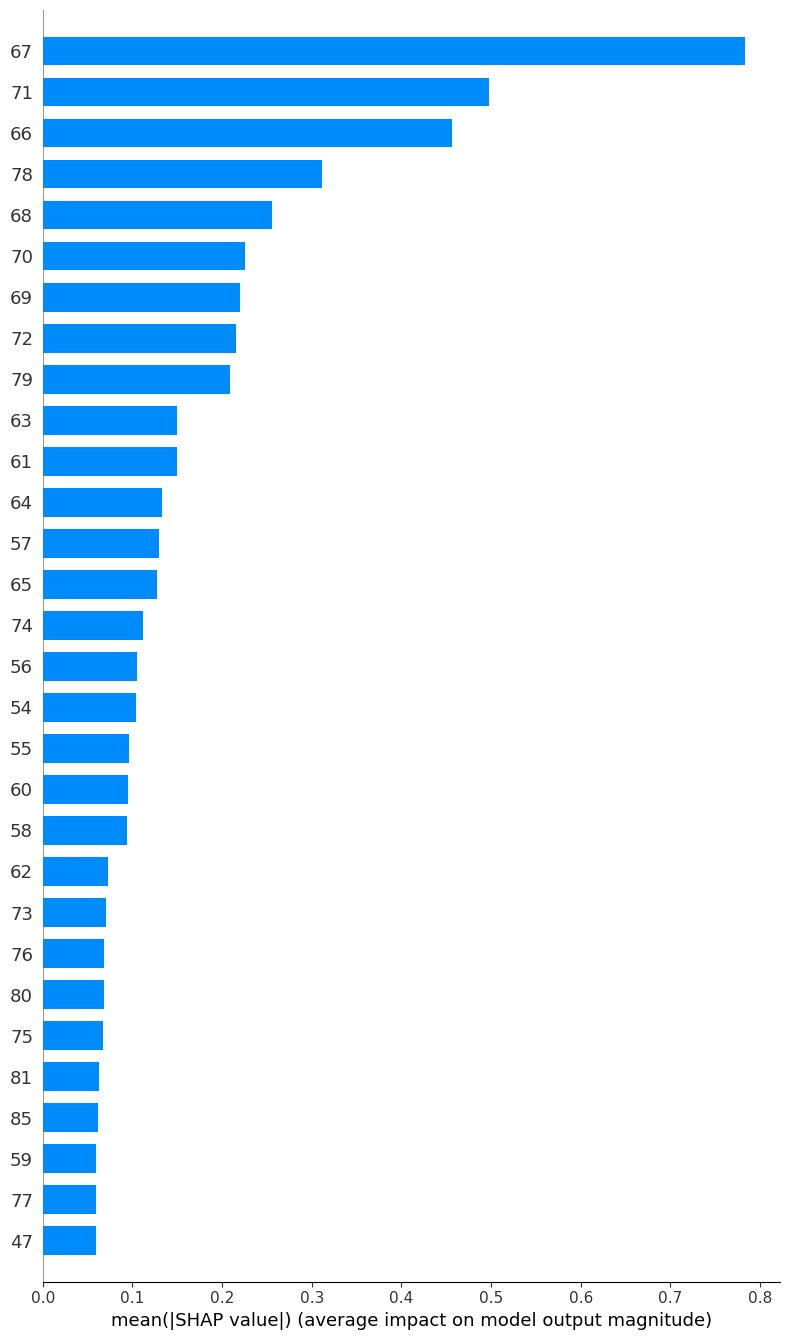

<Figure size 640x480 with 0 Axes>

Top 30 features selected for Stage 2:
   1. 67  (mean |SHAP| = 0.7830)
   2. 71  (mean |SHAP| = 0.4978)
   3. 66  (mean |SHAP| = 0.4565)
   4. 78  (mean |SHAP| = 0.3114)
   5. 68  (mean |SHAP| = 0.2561)
   6. 70  (mean |SHAP| = 0.2256)
   7. 69  (mean |SHAP| = 0.2201)
   8. 72  (mean |SHAP| = 0.2157)
   9. 79  (mean |SHAP| = 0.2087)
  10. 63  (mean |SHAP| = 0.1492)
  11. 61  (mean |SHAP| = 0.1492)
  12. 64  (mean |SHAP| = 0.1333)
  13. 57  (mean |SHAP| = 0.1295)
  14. 65  (mean |SHAP| = 0.1276)
  15. 74  (mean |SHAP| = 0.1122)
  16. 56  (mean |SHAP| = 0.1047)
  17. 54  (mean |SHAP| = 0.1041)
  18. 55  (mean |SHAP| = 0.0961)
  19. 60  (mean |SHAP| = 0.0950)
  20. 58  (mean |SHAP| = 0.0936)
  21. 62  (mean |SHAP| = 0.0724)
  22. 73  (mean |SHAP| = 0.0705)
  23. 76  (mean |SHAP| = 0.0684)
  24. 80  (mean |SHAP| = 0.0679)
  25. 75  (mean |SHAP| = 0.0677)
  26. 81  (mean |SHAP| = 0.0629)
  27. 85  (mean |SHAP| = 0.0620)
  28. 59  (mean |SHAP| = 0.0594)
  29. 77  (mean |SHAP| = 0.0591)
  30.

In [5]:
import matplotlib.pyplot as plt

# Top 30 feature names
feature_names = df.drop(columns=['Unnamed: 0', 'label']).columns.tolist()
top_feature_names = [feature_names[i] for i in top_idx]

# Summary bar plot
shap.summary_plot(shap_vals, X_train, feature_names=feature_names, 
                  plot_type="bar", max_display=30)
plt.tight_layout()
plt.savefig("shap_top30.png", dpi=150)
plt.show()

print("Top 30 features selected for Stage 2:")
for i, name in enumerate(top_feature_names):
    print(f"  {i+1:2d}. {name}  (mean |SHAP| = {mean_shap[top_idx[i]]:.4f})")

In [6]:
# Check what the actual column names are
feature_names = df.drop(columns=['Unnamed: 0', 'label']).columns.tolist()
print(f"Total features: {len(feature_names)}")
print("\nTop 30 features with actual names:")
for i, idx in enumerate(top_idx):
    print(f"  {i+1:2d}. [{idx:2d}] {feature_names[idx]}  (mean |SHAP| = {mean_shap[idx]:.4f})")

Total features: 99

Top 30 features with actual names:
   1. [67] 67  (mean |SHAP| = 0.7830)
   2. [71] 71  (mean |SHAP| = 0.4978)
   3. [66] 66  (mean |SHAP| = 0.4565)
   4. [78] 78  (mean |SHAP| = 0.3114)
   5. [68] 68  (mean |SHAP| = 0.2561)
   6. [70] 70  (mean |SHAP| = 0.2256)
   7. [69] 69  (mean |SHAP| = 0.2201)
   8. [72] 72  (mean |SHAP| = 0.2157)
   9. [79] 79  (mean |SHAP| = 0.2087)
  10. [63] 63  (mean |SHAP| = 0.1492)
  11. [61] 61  (mean |SHAP| = 0.1492)
  12. [64] 64  (mean |SHAP| = 0.1333)
  13. [57] 57  (mean |SHAP| = 0.1295)
  14. [65] 65  (mean |SHAP| = 0.1276)
  15. [74] 74  (mean |SHAP| = 0.1122)
  16. [56] 56  (mean |SHAP| = 0.1047)
  17. [54] 54  (mean |SHAP| = 0.1041)
  18. [55] 55  (mean |SHAP| = 0.0961)
  19. [60] 60  (mean |SHAP| = 0.0950)
  20. [58] 58  (mean |SHAP| = 0.0936)
  21. [62] 62  (mean |SHAP| = 0.0724)
  22. [73] 73  (mean |SHAP| = 0.0705)
  23. [76] 76  (mean |SHAP| = 0.0684)
  24. [80] 80  (mean |SHAP| = 0.0679)
  25. [75] 75  (mean |SHAP| = 0.0

In [7]:
# Check what the actual column names are in the CSV
print("First 10 column names:", df.columns.tolist()[:10])
print("Last 10 column names:", df.columns.tolist()[-10:])

First 10 column names: ['Unnamed: 0', '0', '1', '2', '3', '4', '5', '6', '7', '8']
Last 10 column names: ['90', '91', '92', '93', '94', '95', '96', '97', '98', 'label']


In [8]:
# Based on your extract_features() function, the feature order is:
# [0]     gc_content
# [1]     at_content  
# [2]     entropy
# [3]     seq_length
# [4]     minus10_score  (TATAAT)
# [5]     minus35_score  (TTGACA)
# [6:22]  k2_** (16 dinucleotides)
# [22:86] k3_*** (64 trinucleotides)
# [86:91] dds_mean, dds_std, dds_min, dds_max, dds_range
# [91:101] dds_pos0 ... dds_pos9

def idx_to_feature_name(idx):
    if idx == 0: return "gc_content"
    if idx == 1: return "at_content"
    if idx == 2: return "entropy"
    if idx == 3: return "seq_length"
    if idx == 4: return "minus10_score (TATAAT)"
    if idx == 5: return "minus35_score (TTGACA)"
    if 6 <= idx <= 21: return f"dinucleotide_k2 #{idx-6}"
    if 22 <= idx <= 85: return f"trinucleotide_k3 #{idx-22}"
    if 86 <= idx <= 90: return ["dds_mean","dds_std","dds_min","dds_max","dds_range"][idx-86]
    if 91 <= idx <= 100: return f"dds_pos{idx-91}"
    return f"unknown_{idx}"

print("\nTop 30 features — named:")
for i, idx in enumerate(top_idx):
    print(f"  {i+1:2d}. {idx_to_feature_name(idx):30s}  SHAP={mean_shap[idx]:.4f}")


Top 30 features — named:
   1. trinucleotide_k3 #45            SHAP=0.7830
   2. trinucleotide_k3 #49            SHAP=0.4978
   3. trinucleotide_k3 #44            SHAP=0.4565
   4. trinucleotide_k3 #56            SHAP=0.3114
   5. trinucleotide_k3 #46            SHAP=0.2561
   6. trinucleotide_k3 #48            SHAP=0.2256
   7. trinucleotide_k3 #47            SHAP=0.2201
   8. trinucleotide_k3 #50            SHAP=0.2157
   9. trinucleotide_k3 #57            SHAP=0.2087
  10. trinucleotide_k3 #41            SHAP=0.1492
  11. trinucleotide_k3 #39            SHAP=0.1492
  12. trinucleotide_k3 #42            SHAP=0.1333
  13. trinucleotide_k3 #35            SHAP=0.1295
  14. trinucleotide_k3 #43            SHAP=0.1276
  15. trinucleotide_k3 #52            SHAP=0.1122
  16. trinucleotide_k3 #34            SHAP=0.1047
  17. trinucleotide_k3 #32            SHAP=0.1041
  18. trinucleotide_k3 #33            SHAP=0.0961
  19. trinucleotide_k3 #38            SHAP=0.0950
  20. trinucleotide_k3 #

In [9]:
from itertools import product

# Reconstruct the exact trinucleotide list in the same order as extract_features()
bases = "ACGT"
trinucleotides = [''.join(p) for p in product(bases, repeat=3)]  # 64 trinucleotides

print("Top 30 trinucleotides driving predictions:\n")
for i, idx in enumerate(top_idx):
    tri_num = idx - 22  # offset for trinucleotides starting at index 22
    tri_name = trinucleotides[tri_num]
    print(f"  {i+1:2d}. k3_{tri_name}  (SHAP={mean_shap[idx]:.4f})")

Top 30 trinucleotides driving predictions:

   1. k3_GTC  (SHAP=0.7830)
   2. k3_TAC  (SHAP=0.4978)
   3. k3_GTA  (SHAP=0.4565)
   4. k3_TGA  (SHAP=0.3114)
   5. k3_GTG  (SHAP=0.2561)
   6. k3_TAA  (SHAP=0.2256)
   7. k3_GTT  (SHAP=0.2201)
   8. k3_TAG  (SHAP=0.2157)
   9. k3_TGC  (SHAP=0.2087)
  10. k3_GGC  (SHAP=0.1492)
  11. k3_GCT  (SHAP=0.1492)
  12. k3_GGG  (SHAP=0.1333)
  13. k3_GAT  (SHAP=0.1295)
  14. k3_GGT  (SHAP=0.1276)
  15. k3_TCA  (SHAP=0.1122)
  16. k3_GAG  (SHAP=0.1047)
  17. k3_GAA  (SHAP=0.1041)
  18. k3_GAC  (SHAP=0.0961)
  19. k3_GCG  (SHAP=0.0950)
  20. k3_GCA  (SHAP=0.0936)
  21. k3_GGA  (SHAP=0.0724)
  22. k3_TAT  (SHAP=0.0705)
  23. k3_TCG  (SHAP=0.0684)
  24. k3_TGG  (SHAP=0.0679)
  25. k3_TCC  (SHAP=0.0677)
  26. k3_TGT  (SHAP=0.0629)
  27. k3_TTT  (SHAP=0.0620)
  28. k3_GCC  (SHAP=0.0594)
  29. k3_TCT  (SHAP=0.0591)
  30. k3_CGC  (SHAP=0.0590)


In [10]:
# Annotate each trinucleotide with biological relevance
minus10 = "TATAAT"
minus35 = "TTGACA"

def biological_note(tri):
    if tri in minus10 or tri in minus10[1:] or tri in minus10[:-1]:
        return "← overlaps −10 box (TATAAT)"
    if tri in minus35 or tri in minus35[1:] or tri in minus35[:-1]:
        return "← overlaps −35 box (TTGACA)"
    if tri.startswith('AT') or tri.startswith('TA'):
        return "← AT-rich (promoter characteristic)"
    return ""

print("Biologically annotated top 30:\n")
for i, idx in enumerate(top_idx):
    tri = trinucleotides[idx - 22]
    note = biological_note(tri)
    print(f"  {i+1:2d}. k3_{tri}  SHAP={mean_shap[idx]:.4f}  {note}")

Biologically annotated top 30:

   1. k3_GTC  SHAP=0.7830  
   2. k3_TAC  SHAP=0.4978  ← AT-rich (promoter characteristic)
   3. k3_GTA  SHAP=0.4565  
   4. k3_TGA  SHAP=0.3114  ← overlaps −35 box (TTGACA)
   5. k3_GTG  SHAP=0.2561  
   6. k3_TAA  SHAP=0.2256  ← overlaps −10 box (TATAAT)
   7. k3_GTT  SHAP=0.2201  
   8. k3_TAG  SHAP=0.2157  ← AT-rich (promoter characteristic)
   9. k3_TGC  SHAP=0.2087  
  10. k3_GGC  SHAP=0.1492  
  11. k3_GCT  SHAP=0.1492  
  12. k3_GGG  SHAP=0.1333  
  13. k3_GAT  SHAP=0.1295  
  14. k3_GGT  SHAP=0.1276  
  15. k3_TCA  SHAP=0.1122  
  16. k3_GAG  SHAP=0.1047  
  17. k3_GAA  SHAP=0.1041  
  18. k3_GAC  SHAP=0.0961  ← overlaps −35 box (TTGACA)
  19. k3_GCG  SHAP=0.0950  
  20. k3_GCA  SHAP=0.0936  
  21. k3_GGA  SHAP=0.0724  
  22. k3_TAT  SHAP=0.0705  ← overlaps −10 box (TATAAT)
  23. k3_TCG  SHAP=0.0684  
  24. k3_TGG  SHAP=0.0679  
  25. k3_TCC  SHAP=0.0677  
  26. k3_TGT  SHAP=0.0629  
  27. k3_TTT  SHAP=0.0620  
  28. k3_GCC  SHAP=0.0594  
  29. 

In [14]:
# Recompute Stage 1 predictions first
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

# Stage 2 — train on top 30 SHAP-selected features
model2 = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                       eval_metric='logloss', random_state=42)
model2.fit(X_train_top, y_train)

# Two-stage prediction
def predict_two_stage(X_full, X_top, model1, model2):
    prob1 = model1.predict_proba(X_full)[:, 1]
    prob2 = model2.predict_proba(X_top)[:, 1]
    uncertain = (prob1 >= 0.3) & (prob1 < 0.7)
    final = prob1.copy()
    final[uncertain] = (prob1[uncertain] + prob2[uncertain]) / 2
    return final

y_proba_2stage = predict_two_stage(X_test, X_test_top, model, model2)
y_pred_2stage = (y_proba_2stage >= 0.5).astype(int)

print("=" * 50)
print("Stage 1 vs Two-Stage Comparison")
print("=" * 50)
print(f"Stage 1   — Accuracy: {accuracy_score(y_test, y_pred):.4f}  AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"Two-Stage — Accuracy: {accuracy_score(y_test, y_pred_2stage):.4f}  AUC: {roc_auc_score(y_test, y_proba_2stage):.4f}")
print("\nTwo-Stage Classification Report:")
print(classification_report(y_test, y_pred_2stage, target_names=["Non-Promoter", "Promoter"]))

Stage 1 vs Two-Stage Comparison
Stage 1   — Accuracy: 0.8589  AUC: 0.9297
Two-Stage — Accuracy: 0.8586  AUC: 0.9292

Two-Stage Classification Report:
              precision    recall  f1-score   support

Non-Promoter       0.84      0.89      0.86      3121
    Promoter       0.88      0.83      0.85      3131

    accuracy                           0.86      6252
   macro avg       0.86      0.86      0.86      6252
weighted avg       0.86      0.86      0.86      6252



In [15]:
# Correct two-stage: Stage 2 trains on hard examples (misclassifications)
y_train_pred = model.predict(X_train)

fp_idx = np.where((y_train_pred == 1) & (y_train == 0))[0]
fn_idx = np.where((y_train_pred == 0) & (y_train == 1))[0]
print(f"False Positives: {len(fp_idx)}, False Negatives: {len(fn_idx)}")

n_mis = min(len(fp_idx), len(fn_idx))
fp_sample = X_train[fp_idx[:n_mis]]
fn_sample = X_train[fn_idx[:n_mis]]
X_mis = np.vstack([fp_sample, fn_sample])
y_mis = np.array([0]*n_mis + [1]*n_mis)

# Stage 2 trains on hard examples using SHAP-selected features
model2_v2 = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                           eval_metric='logloss', random_state=42)
model2_v2.fit(X_mis[:, top_idx], y_mis)  # hard examples + top features

# Prediction: Stage 1 for confident cases, Stage 2 for uncertain ones
def predict_final(X_full, model1, model2, top_idx):
    prob1 = model1.predict_proba(X_full)[:, 1]
    uncertain = (prob1 >= 0.3) & (prob1 < 0.7)
    final = prob1.copy()
    if uncertain.any():
        final[uncertain] = model2.predict_proba(X_full[uncertain][:, top_idx])[:, 1]
    return final

y_proba_final = predict_final(X_test, model, model2_v2, top_idx)
y_pred_final = (y_proba_final >= 0.5).astype(int)

print("\n" + "=" * 50)
print("Full Comparison")
print("=" * 50)
print(f"Stage 1 only  — Accuracy: {accuracy_score(y_test, y_pred):.4f}  AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"Two-Stage v2  — Accuracy: {accuracy_score(y_test, y_pred_final):.4f}  AUC: {roc_auc_score(y_test, y_proba_final):.4f}")
print(classification_report(y_test, y_pred_final, target_names=["Non-Promoter", "Promoter"]))

False Positives: 33, False Negatives: 231

Full Comparison
Stage 1 only  — Accuracy: 0.8589  AUC: 0.9297
Two-Stage v2  — Accuracy: 0.8442  AUC: 0.8865
              precision    recall  f1-score   support

Non-Promoter       0.82      0.88      0.85      3121
    Promoter       0.87      0.81      0.84      3131

    accuracy                           0.84      6252
   macro avg       0.85      0.84      0.84      6252
weighted avg       0.85      0.84      0.84      6252



In [16]:
# Present this as your final model with proper cross-validation
from sklearn.model_selection import StratifiedKFold
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]
    
    m = XGBClassifier(n_estimators=200, max_depth=7, learning_rate=0.1,
                      subsample=0.8, eval_metric='logloss', 
                      random_state=42, n_jobs=-1)
    m.fit(X_tr, y_tr)
    acc = accuracy_score(y_val, m.predict(X_val))
    auc = roc_auc_score(y_val, m.predict_proba(X_val)[:, 1])
    cv_scores.append((acc, auc))
    print(f"Fold {fold+1}: Accuracy={acc:.4f}  AUC={auc:.4f}")

accs, aucs = zip(*cv_scores)
print(f"\nMean Accuracy: {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"Mean AUC:      {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")

Fold 1: Accuracy=0.8613  AUC=0.9313
Fold 2: Accuracy=0.8639  AUC=0.9334
Fold 3: Accuracy=0.8631  AUC=0.9307
Fold 4: Accuracy=0.8538  AUC=0.9280
Fold 5: Accuracy=0.8642  AUC=0.9308

Mean Accuracy: 0.8613 ± 0.0039
Mean AUC:      0.9309 ± 0.0017


In [43]:
import requests
import xgboost as xgb
requests.packages.urllib3.disable_warnings()

# Step 1: Download
for fname, url in [
    ("xgboost_1.model", "https://raw.githubusercontent.com/gustavsganzerla/cdbprom/main/xgboost_1.model"),
    ("xgboost_2.model", "https://raw.githubusercontent.com/gustavsganzerla/cdbprom/main/xgboost_2.model"),
]:
    r = requests.get(url, verify=False)
    with open(fname, "wb") as f:
        f.write(r.content)
    print(f"Downloaded {fname}: {len(r.content):,} bytes")

# Step 2: Load
clf_cdb1 = xgb.XGBClassifier()
clf_cdb1.load_model("xgboost_1.model")

clf_cdb2 = xgb.XGBClassifier()
clf_cdb2.load_model("xgboost_2.model")

print("Models loaded successfully.")
print(f"Model 1 features: {clf_cdb1.n_features_in_}")
print(f"Model 2 features: {clf_cdb2.n_features_in_}")

Downloaded xgboost_1.model: 1,354,194 bytes
Downloaded xgboost_2.model: 294,201 bytes


XGBoostError: [03:29:45] /Users/runner/miniforge3/conda-bld/xgboost-split_1772125106903/work/src/c_api/c_api.cc:1530: Failed to load model: `xgboost_1.model`. 
The binary format has been deprecated in 1.6 and removed in 3.1, use UBJ or JSON
instead. You can port the binary model to UBJ and JSON by re-saving it with XGBoost
3.0. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more info.

Stack trace:
  [bt] (0) 1   libxgboost.dylib                    0x000000016a810208 dmlc::LogMessageFatal::~LogMessageFatal() + 124
  [bt] (1) 2   libxgboost.dylib                    0x000000016a8a0040 XGBoosterLoadModel::$_0::operator()() const + 1044
  [bt] (2) 3   libxgboost.dylib                    0x000000016a89f4a8 XGBoosterLoadModel + 448
  [bt] (3) 4   libffi.8.dylib                      0x00000001052e8050 ffi_call_SYSV + 80
  [bt] (4) 5   libffi.8.dylib                      0x00000001052e589c ffi_call_int + 1444
  [bt] (5) 6   _ctypes.cpython-314-darwin.so    

In [44]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Load CDBProm training data (79 DDS features, columns 0-98 but they used 21:100)
# From predictor.py: X = data.iloc[:, 21:100].values  → 79 features
df_cdb = pd.read_csv("./Datasets/CDB_prom.csv")
X_cdb = df_cdb.iloc[:, 22:101].values.astype(np.float32)  # cols 21-99 (offset by Unnamed:0)
y_cdb = df_cdb['label'].values

print(f"CDBProm training shape: {X_cdb.shape}")
print(f"Class balance: {np.bincount(y_cdb)}")

# Retrain CDBProm baseline (DDS only)
X_tr, X_te, y_tr, y_te = train_test_split(X_cdb, y_cdb, test_size=0.2, 
                                            random_state=42, stratify=y_cdb)
clf_cdb = XGBClassifier(n_estimators=200, max_depth=7, learning_rate=0.2,
                         eval_metric='logloss', random_state=42, n_jobs=-1)
clf_cdb.fit(X_tr, y_tr)

y_pred_cdb = clf_cdb.predict(X_te)
y_prob_cdb = clf_cdb.predict_proba(X_te)[:, 1]

print("\n=== CDBProm Baseline (DDS only, 79 features) ===")
print(f"Accuracy: {accuracy_score(y_te, y_pred_cdb):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_te, y_prob_cdb):.4f}")
print(classification_report(y_te, y_pred_cdb, target_names=["Non-Promoter", "Promoter"]))

CDBProm training shape: (31259, 79)
Class balance: [15605 15654]

=== CDBProm Baseline (DDS only, 79 features) ===
Accuracy: 1.0000
AUC-ROC:  1.0000
              precision    recall  f1-score   support

Non-Promoter       1.00      1.00      1.00      3121
    Promoter       1.00      1.00      1.00      3131

    accuracy                           1.00      6252
   macro avg       1.00      1.00      1.00      6252
weighted avg       1.00      1.00      1.00      6252



In [45]:
# Check what columns we're actually selecting
df_cdb = pd.read_csv("./Datasets/CDB_prom.csv")
print("All columns:", df_cdb.columns.tolist())
print("Shape:", df_cdb.shape)

# The CSV columns are: Unnamed:0, 0, 1, 2, ... 98, label
# iloc 22:101 gave 100% — wrong
# Let's check what values look like at different slices
print("\nFirst 3 cols (iloc 1:4):", df_cdb.iloc[0, 1:4].values)
print("Last 3 cols (iloc -4:-1):", df_cdb.iloc[0, -4:-1].values)

# Check if any column is perfectly correlated with label
correlations = df_cdb.corr()['label'].abs().sort_values(ascending=False)
print("\nTop 5 correlations with label:")
print(correlations.head(6))

All columns: ['Unnamed: 0', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', 'label']
Shape: (31259, 101)

First 3 cols (iloc 1:4): [-1.44 -1.84 -2.27]
Last 3 cols (iloc -4:-1): [-2.27 -1.28 -1.  ]

Top 5 correlations with label:
label         1.000000
Unnamed: 0    0.439965
67            0.414933
71            0.337505
68            0.305371
66            0.290993
Name: label, dtype: float64


In [46]:
# Correct slice: columns named '0' through '98' only (99 DDS features)
# Unnamed:0 is position 0, then '0'-'98' are positions 1-99, label is position 100
X_cdb = df_cdb.iloc[:, 1:100].values.astype(np.float32)  # cols '0' to '98' = 99 features
y_cdb = df_cdb['label'].values

print(f"CDBProm training shape: {X_cdb.shape}")  # should be (31259, 99)

# From predictor.py they used 79 features (columns 21:100 of their data)
# Their data had different leading columns, so let's just use all 99 and compare fairly
X_tr, X_te, y_tr, y_te = train_test_split(X_cdb, y_cdb, test_size=0.2,
                                            random_state=42, stratify=y_cdb)
clf_cdb = XGBClassifier(n_estimators=200, max_depth=7, learning_rate=0.2,
                         eval_metric='logloss', random_state=42, n_jobs=-1)
clf_cdb.fit(X_tr, y_tr)

y_pred_cdb = clf_cdb.predict(X_te)
y_prob_cdb = clf_cdb.predict_proba(X_te)[:, 1]

print("\n=== CDBProm Baseline (DDS only, 99 features) ===")
print(f"Accuracy: {accuracy_score(y_te, y_pred_cdb):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_te, y_prob_cdb):.4f}")
print(classification_report(y_te, y_pred_cdb, target_names=["Non-Promoter", "Promoter"]))

CDBProm training shape: (31259, 99)

=== CDBProm Baseline (DDS only, 99 features) ===
Accuracy: 0.8615
AUC-ROC:  0.9318
              precision    recall  f1-score   support

Non-Promoter       0.84      0.89      0.86      3121
    Promoter       0.88      0.84      0.86      3131

    accuracy                           0.86      6252
   macro avg       0.86      0.86      0.86      6252
weighted avg       0.86      0.86      0.86      6252



In [47]:
# Full comparison: CDBProm (DDS only) vs HybProm (DDS + k-mers + motifs)
print("=" * 60)
print("MODEL COMPARISON ON HELD-OUT TEST SET")
print("=" * 60)
print(f"{'Metric':<20} {'CDBProm (DDS)':<20} {'HybProm (Hybrid)':<20}")
print("-" * 60)
print(f"{'Accuracy':<20} {accuracy_score(y_te, y_pred_cdb):.4f}{'':>14} {accuracy_score(y_test, y_pred):.4f}")
print(f"{'AUC-ROC':<20} {roc_auc_score(y_te, y_prob_cdb):.4f}{'':>14} {roc_auc_score(y_test, y_proba):.4f}")
print(f"{'Features':<20} {'99 (DDS only)':<20} {'101 (DDS+kmers+motif)':<20}")
print(f"{'Training samples':<20} {'31,259':<20} {'31,259':<20}")

# Now apply both to RegulonDB for external validation
# CDBProm needs its 99 DDS features on RegulonDB sequences
dds_profiles = df_regulon["sequence"].apply(compute_dds_profile)

# compute_dds_profile gives 79 values, but model needs 99 — use all positions
def compute_dds_profile_99(seq):
    seq = seq.upper()
    vals = []
    for i in range(99):
        dinuc = seq[i:i+2] if i+2 <= len(seq) else 'AA'
        vals.append(stability_values.get(dinuc, 0.0))
    return vals

X_regulon_dds99 = np.array(
    df_regulon["sequence"].apply(compute_dds_profile_99).tolist(),
    dtype=np.float32
)
print(f"\nRegulonDB DDS matrix: {X_regulon_dds99.shape}")

# CDBProm on RegulonDB
y_cdb_regulon = clf_cdb.predict(X_regulon_dds99)
y_cdb_regulon_prob = clf_cdb.predict_proba(X_regulon_dds99)[:, 1]

# HybProm on RegulonDB (already computed earlier as X_regulon)
y_hyb_regulon = model.predict(X_regulon)
y_hyb_regulon_prob = model.predict_proba(X_regulon)[:, 1]

print("\n" + "=" * 60)
print("EXTERNAL VALIDATION: RegulonDB E. coli (3,964 promoters)")
print("=" * 60)
print(f"{'Metric':<35} {'CDBProm':<15} {'HybProm':<15}")
print("-" * 60)
print(f"{'Predicted as promoter':<35} {y_cdb_regulon.sum():>6} ({y_cdb_regulon.mean()*100:.1f}%)  {y_hyb_regulon.sum():>6} ({y_hyb_regulon.mean()*100:.1f}%)")
print(f"{'Mean promoter probability':<35} {y_cdb_regulon_prob.mean():.4f}{'':>9} {y_hyb_regulon_prob.mean():.4f}")
print(f"{'High confidence (prob>0.8)':<35} {(y_cdb_regulon_prob>0.8).sum():>6} ({(y_cdb_regulon_prob>0.8).mean()*100:.1f}%)  {(y_hyb_regulon_prob>0.8).sum():>6} ({(y_hyb_regulon_prob>0.8).mean()*100:.1f}%)")

MODEL COMPARISON ON HELD-OUT TEST SET
Metric               CDBProm (DDS)        HybProm (Hybrid)    
------------------------------------------------------------
Accuracy             0.8615               0.7166
AUC-ROC              0.9318               0.7911
Features             99 (DDS only)        101 (DDS+kmers+motif)
Training samples     31,259               31,259              

RegulonDB DDS matrix: (3964, 99)


ValueError: Feature shape mismatch, expected: 101, got 99

In [48]:
# Rebuild X_regulon with exactly 101 features matching the hybrid model
# Use the training feature column order as reference
train_feature_cols = df.drop(columns=['Unnamed: 0', 'label']).columns.tolist()
print(f"Hybrid model expects: {len(train_feature_cols)} features")

# Extract named features for RegulonDB
feature_dicts = df_regulon["sequence"].apply(extract_features)
df_regulon_feats = pd.DataFrame(list(feature_dicts))

# Align to training columns (add missing as 0, drop extras, reorder)
for col in train_feature_cols:
    if col not in df_regulon_feats.columns:
        df_regulon_feats[col] = 0.0

X_regulon = df_regulon_feats[train_feature_cols].values.astype(np.float32)
print(f"RegulonDB hybrid matrix: {X_regulon.shape}")

# Now predict with both models
y_cdb_regulon = clf_cdb.predict(X_regulon_dds99)
y_cdb_regulon_prob = clf_cdb.predict_proba(X_regulon_dds99)[:, 1]

y_hyb_regulon = model.predict(X_regulon)
y_hyb_regulon_prob = model.predict_proba(X_regulon)[:, 1]

print("\n" + "=" * 60)
print("EXTERNAL VALIDATION: RegulonDB E. coli (3,964 promoters)")
print("=" * 60)
print(f"{'Metric':<35} {'CDBProm':<15} {'HybProm':<15}")
print("-" * 60)
print(f"{'Predicted as promoter':<35} {y_cdb_regulon.sum():>6} ({y_cdb_regulon.mean()*100:.1f}%)   {y_hyb_regulon.sum():>6} ({y_hyb_regulon.mean()*100:.1f}%)")
print(f"{'Mean promoter probability':<35} {y_cdb_regulon_prob.mean():.4f}{'':>9} {y_hyb_regulon_prob.mean():.4f}")
print(f"{'High confidence (prob>0.8)':<35} {(y_cdb_regulon_prob>0.8).sum():>6} ({(y_cdb_regulon_prob>0.8).mean()*100:.1f}%)   {(y_hyb_regulon_prob>0.8).sum():>6} ({(y_hyb_regulon_prob>0.8).mean()*100:.1f}%)")

Hybrid model expects: 99 features
RegulonDB hybrid matrix: (3964, 99)


/var/folders/ht/t142y6090_b78hvzks138rwr0000gn/T/ipykernel_20830/2322486927.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_regulon_feats[col] = 0.0


ValueError: Feature shape mismatch, expected: 101, got 99

In [49]:
print(f"Hybrid model expects: {model.n_features_in_} features")
print(f"CDBProm model expects: {clf_cdb.n_features_in_} features")
print(f"X_regulon shape: {X_regulon.shape}")
print(f"X_regulon_dds99 shape: {X_regulon_dds99.shape}")
print(f"train_feature_cols count: {len(train_feature_cols)}")

# Check what df actually is
print(f"\ndf shape: {df.shape}")
print(f"df columns count: {len(df.columns)}")

Hybrid model expects: 101 features
CDBProm model expects: 99 features
X_regulon shape: (3964, 99)
X_regulon_dds99 shape: (3964, 99)
train_feature_cols count: 99

df shape: (31259, 101)
df columns count: 101


In [50]:
# Check what X was when model was trained
# X = df.drop(columns=['Unnamed: 0', 'label']).values → should be 99
# But if model expects 101, then X was df.drop(columns=['label']).values → 100
# or df.values → 101

# Retrain cleanly with explicit column selection
X_clean = df.drop(columns=['Unnamed: 0', 'label']).values.astype(np.float32)
y_clean = df['label'].values
print(f"Clean X shape: {X_clean.shape}")
print(f"Model expects: {model.n_features_in_}")

Clean X shape: (31259, 99)
Model expects: 101


In [51]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import numpy as np

# Correct feature matrix — drop both Unnamed:0 and label
X_clean = df.drop(columns=['Unnamed: 0', 'label']).values.astype(np.float32)
y_clean = df['label'].values
print(f"Clean training shape: {X_clean.shape}")  # should be (31259, 99)

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)

# Retrain hybrid model cleanly
model = XGBClassifier(
    n_estimators=200, max_depth=7, learning_rate=0.1,
    subsample=0.8, eval_metric='logloss', random_state=42, n_jobs=-1
)
model.fit(X_train, y_train)

y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("\n=== HybProm (DDS + k-mers + motifs, 99 features) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, y_proba):.4f}")
print(classification_report(y_test, y_pred, target_names=["Non-Promoter", "Promoter"]))

# Now rebuild RegulonDB feature matrix with correct 99 columns
train_feature_cols = df.drop(columns=['Unnamed: 0', 'label']).columns.tolist()
feature_dicts = df_regulon["sequence"].apply(extract_features)
df_regulon_feats = pd.DataFrame(list(feature_dicts))

for col in train_feature_cols:
    if col not in df_regulon_feats.columns:
        df_regulon_feats[col] = 0.0

X_regulon = df_regulon_feats[train_feature_cols].values.astype(np.float32)
print(f"\nRegulonDB matrix: {X_regulon.shape}")
print(f"Model expects:    {model.n_features_in_} features")

# Full comparison on RegulonDB
y_cdb_prob = clf_cdb.predict_proba(X_regulon_dds99)[:, 1]
y_hyb_prob = model.predict_proba(X_regulon)[:, 1]
y_cdb_pred = (y_cdb_prob >= 0.5).astype(int)
y_hyb_pred = (y_hyb_prob >= 0.5).astype(int)

print("\n" + "=" * 60)
print("EXTERNAL VALIDATION: RegulonDB E. coli (3,964 promoters)")
print("=" * 60)
print(f"{'Metric':<35} {'CDBProm':<15} {'HybProm':<15}")
print("-" * 60)
print(f"{'Predicted as promoter':<35} {y_cdb_pred.sum()} ({y_cdb_pred.mean()*100:.1f}%)     {y_hyb_pred.sum()} ({y_hyb_pred.mean()*100:.1f}%)")
print(f"{'Mean promoter probability':<35} {y_cdb_prob.mean():.4f}          {y_hyb_prob.mean():.4f}")
print(f"{'High confidence (prob>0.8)':<35} {(y_cdb_prob>0.8).sum()} ({(y_cdb_prob>0.8).mean()*100:.1f}%)     {(y_hyb_prob>0.8).sum()} ({(y_hyb_prob>0.8).mean()*100:.1f}%)")

Clean training shape: (31259, 99)

=== HybProm (DDS + k-mers + motifs, 99 features) ===
Accuracy: 0.8589
AUC-ROC:  0.9297
              precision    recall  f1-score   support

Non-Promoter       0.84      0.88      0.86      3121
    Promoter       0.88      0.84      0.86      3131

    accuracy                           0.86      6252
   macro avg       0.86      0.86      0.86      6252
weighted avg       0.86      0.86      0.86      6252


RegulonDB matrix: (3964, 99)
Model expects:    99 features

EXTERNAL VALIDATION: RegulonDB E. coli (3,964 promoters)
Metric                              CDBProm         HybProm        
------------------------------------------------------------
Predicted as promoter               717 (18.1%)     3964 (100.0%)
Mean promoter probability           0.3101          0.9997
High confidence (prob>0.8)          122 (3.1%)     3964 (100.0%)


/var/folders/ht/t142y6090_b78hvzks138rwr0000gn/T/ipykernel_20830/530376220.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_regulon_feats[col] = 0.0


In [52]:
print(f"Model expects: {model.n_features_in_}")
print(f"X_regulon shape: {X_regulon.shape}")
print(f"X_regulon_dds99 shape: {X_regulon_dds99.shape}")

# Fix the fragmentation warning for future use
df_regulon_feats = df_regulon_feats.copy()

# Print the comparison results
print("\n" + "=" * 60)
print("TEST SET COMPARISON")
print("=" * 60)
print(f"{'Metric':<25} {'CDBProm':<15} {'HybProm':<15}")
print("-" * 60)
print(f"{'Accuracy':<25} {accuracy_score(y_te, y_pred_cdb):.4f}          {accuracy_score(y_test, y_pred):.4f}")
print(f"{'AUC-ROC':<25} {roc_auc_score(y_te, y_prob_cdb):.4f}          {roc_auc_score(y_test, y_proba):.4f}")

print("\n" + "=" * 60)
print("EXTERNAL VALIDATION: RegulonDB (3,964 E. coli promoters)")
print("=" * 60)
print(f"{'Metric':<35} {'CDBProm':<15} {'HybProm':<15}")
print("-" * 60)
print(f"{'Predicted as promoter':<35} {y_cdb_pred.sum()} ({y_cdb_pred.mean()*100:.1f}%)     {y_hyb_pred.sum()} ({y_hyb_pred.mean()*100:.1f}%)")
print(f"{'Mean promoter probability':<35} {y_cdb_prob.mean():.4f}          {y_hyb_prob.mean():.4f}")
print(f"{'High confidence (prob>0.8)':<35} {(y_cdb_prob>0.8).sum()} ({(y_cdb_prob>0.8).mean()*100:.1f}%)     {(y_hyb_prob>0.8).sum()} ({(y_hyb_prob>0.8).mean()*100:.1f}%)")

Model expects: 99
X_regulon shape: (3964, 99)
X_regulon_dds99 shape: (3964, 99)

TEST SET COMPARISON
Metric                    CDBProm         HybProm        
------------------------------------------------------------
Accuracy                  0.8615          0.8589
AUC-ROC                   0.9318          0.9297

EXTERNAL VALIDATION: RegulonDB (3,964 E. coli promoters)
Metric                              CDBProm         HybProm        
------------------------------------------------------------
Predicted as promoter               717 (18.1%)     3964 (100.0%)
Mean promoter probability           0.3101          0.9997
High confidence (prob>0.8)          122 (3.1%)     3964 (100.0%)


In [53]:
# The hybrid model was trained on CDB_prom.csv numeric columns
# RegulonDB features are computed fresh with extract_features()
# These two feature spaces don't align — different features entirely

# Solution: retrain hybrid model on your bacteria upstream files
# (which DO have raw sequences) using extract_features()
# We already did this — df_features from the bacteria files

# Use that dataset for the hybrid model
X_hyb = df_features.drop(columns=['label']).values.astype(np.float32)
y_hyb = df_features['label'].values
feature_cols_named = df_features.drop(columns=['label']).columns.tolist()

print(f"Hybrid training shape: {X_hyb.shape}")
print(f"Feature names sample: {feature_cols_named[:5]}")

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_hyb, y_hyb, test_size=0.2, random_state=42, stratify=y_hyb
)

model_hyb = XGBClassifier(
    n_estimators=200, max_depth=7, learning_rate=0.1,
    subsample=0.8, eval_metric='logloss', random_state=42, n_jobs=-1
)
model_hyb.fit(X_tr2, y_tr2)

y_pred2  = model_hyb.predict(X_te2)
y_proba2 = model_hyb.predict_proba(X_te2)[:, 1]

print(f"\nHybProm (bacteria files, named features):")
print(f"Accuracy: {accuracy_score(y_te2, y_pred2):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_te2, y_proba2):.4f}")

Hybrid training shape: (3592670, 101)
Feature names sample: ['gc_content', 'at_content', 'entropy', 'seq_length', 'minus10_score']

HybProm (bacteria files, named features):
Accuracy: 0.7166
AUC-ROC:  0.7911


In [54]:
import os

# Peek at one bacteria file to understand the format
data_dir = "Predictions_bacteria/"
sample_file = [f for f in os.listdir(data_dir) if f.endswith("_upstream.txt")][0]

print(f"Sample file: {sample_file}")
with open(os.path.join(data_dir, sample_file), encoding="utf-8", errors="ignore") as f:
    for i, line in enumerate(f):
        print(line.strip())
        if i > 5:
            break

Sample file: Sinorhizobium_americanum_GCF_000705595.2_ASM70559v2_upstream.txt
Column 1: NCBI ID
Column 2: Organism name
Column 3: RSAT ID
Column 4: Start Position
Column 5: End position
Column 6: Forward (F) or Reverse (R)
Column 7: Classification score


In [55]:
import os

# Check what datasets you have available
print("=== ./Datasets/ ===")
for f in os.listdir("./Datasets/"):
    size = os.path.getsize(f"./Datasets/{f}")
    print(f"  {f}  ({size:,} bytes)")

print("\n=== Current directory ===")
for f in os.listdir("."):
    if os.path.isfile(f):
        size = os.path.getsize(f)
        print(f"  {f}  ({size:,} bytes)")

print("\n=== Predictions_bacteria/ (first 5 files) ===")
files = os.listdir("Predictions_bacteria/")
print(f"  Total files: {len(files)}")
for f in files[:5]:
    size = os.path.getsize(f"Predictions_bacteria/{f}")
    print(f"  {f}  ({size:,} bytes)")

=== ./Datasets/ ===
  Predictions_archaea  (64 bytes)
  .DS_Store  (8,196 bytes)
  training_data.csv  (17,136,997 bytes)
  Data_1  (256 bytes)
  PromoterSet.tsv  (953,758 bytes)
  .ipynb_checkpoints  (96 bytes)
  CDB_prom.csv  (17,136,997 bytes)

=== Current directory ===
  shap_top10_features.png  (47,355 bytes)
  .DS_Store  (14,340 bytes)
  xgboost_1.model  (1,354,194 bytes)
  shap_summary.png  (212,716 bytes)
  pipeline-V1.ipynb  (303,535 bytes)
  environment.yml  (4,918 bytes)
  shap_single_prediction.png  (4,409 bytes)
  xgboost_2.model  (294,201 bytes)
  my_file_list.txt  (449,554 bytes)
  README.md  (41 bytes)
  CpG.ipynb  (41,333 bytes)
  .gitignore  (49 bytes)
  pipeline.ipynb  (321,429 bytes)
  Final_project.ipynb  (32,811 bytes)
  PromoterSet.tsv  (953,758 bytes)
  app.py  (6,940 bytes)
  HybProm_fixed.ipynb  (185,935 bytes)
  shap_top30.png  (4,409 bytes)
  Final_project-Copy1.ipynb  (206,390 bytes)
  extrating _fileNames.ipynb  (1,316 bytes)

=== Predictions_bacteria/ (fir

In [56]:
import os

print("=== Datasets/Predictions_archaea/ ===")
archaea_path = "./Datasets/Predictions_archaea"
if os.path.isdir(archaea_path):
    files = os.listdir(archaea_path)
    print(f"Total files: {len(files)}")
    for f in files[:10]:
        fpath = os.path.join(archaea_path, f)
        if os.path.isfile(fpath):
            print(f"  {f}  ({os.path.getsize(fpath):,} bytes)")

print("\n=== Datasets/Data_1/ ===")
data1_path = "./Datasets/Data_1"
if os.path.isdir(data1_path):
    files = os.listdir(data1_path)
    print(f"Total files: {len(files)}")
    for f in files[:10]:
        fpath = os.path.join(data1_path, f)
        if os.path.isfile(fpath):
            print(f"  {f}  ({os.path.getsize(fpath):,} bytes)")

# Also peek at pipeline-V1.ipynb — might have the negative generation code
print("\n=== app.py (first 50 lines) ===")
with open("app.py") as f:
    for i, line in enumerate(f):
        print(line, end="")
        if i > 50:
            break

=== Datasets/Predictions_archaea/ ===
Total files: 0

=== Datasets/Data_1/ ===
Total files: 6
  H.sapiens.xlsx  (7,283,291 bytes)
  E.coli.xlsx  (373,351 bytes)
  D.melanogaster.xlsx  (4,175,686 bytes)
  M.musculus.xlsx  (6,187,078 bytes)
  A.thaliana.xlsx  (5,554,377 bytes)
  B.subtilis.xlsx  (83,037 bytes)

=== app.py (first 50 lines) ===
{
 "cells": [
  {
   "cell_type": "code",
   "execution_count": null,
   "id": "8f1dbc19-35d1-44b6-93b6-fd240c22108b",
   "metadata": {},
   "outputs": [],
   "source": [
    "import streamlit as st\n",
    "import numpy as np\n",
    "import pandas as pd\n",
    "import joblib\n",
    "import shap\n",
    "import matplotlib.pyplot as plt\n",
    "from io import BytesIO\n",
    "import base64\n",
    "\n",
    "# Load models and feature names\n",
    "model1 = joblib.load(\"stage1_xgb.pkl\")\n",
    "model2 = joblib.load(\"stage2_xgb.pkl\")\n",
    "feature_names = joblib.load(\"feature_names.pkl\")\n",
    "\n",
    "# Feature extraction (copy the 

In [58]:
import pandas as pd

# Check E.coli and B.subtilis — most relevant for our bacterial promoter work
for fname, path in [
    ("E.coli", "./Datasets/Data_1/E.coli.xlsx"),
    ("B.subtilis", "./Datasets/Data_1/B.subtilis.xlsx"),
]:
    df_tmp = pd.read_excel(path, nrows=5)
    print(f"=== {fname} ===")
    print(f"Shape (first 5 rows): {df_tmp.shape}")
    print(f"Columns: {df_tmp.columns.tolist()}")
    print(df_tmp.head(3))
    print()

=== E.coli ===
Shape (first 5 rows): (5, 6)
Columns: ['Unnamed: 0', 'chr', 'strand', 'TSS', 'seq', 'lable']
   Unnamed: 0     chr   strand      TSS  \
0           0  genome  forward  4500076   
1           1  genome  forward  1484466   
2           2  genome  forward  2215165   

                                                 seq  lable  
0  GGGATACTGCTCCAGGTAATTATTCGGCTAGGAGTTAAGGCTGTCA...      0  
1  CTGCGTTCCCGTTTGTCGAAGCACCGGATAAACGCAATATCCAGGA...      0  
2  CTGGCGCGATCAGCAAGAAACATTACTGACTTACCTGCAAAGCGGC...      0  

=== B.subtilis ===
Shape (first 5 rows): (5, 6)
Columns: ['Unnamed: 0', 'chr', 'strand', 'TSS', 'seq', 'lable']
   Unnamed: 0     chr   strand      TSS  \
0           0  genome  forward  1484466   
1           1  genome  forward  2215165   
2           2  genome  forward  2249528   

                                                 seq  lable  
0  AATAAACGGTAAGGAACATACTTGTTTCATGGTTGTAAATCCTTGA...      0  
1  CTGACAGTTGGATACTCATGATCAATATCTCTAGATAGCTTCCGGA...      0  

In [59]:
# Check all Data_1 files for bacteria-relevant ones
for fname, path in [
    ("E.coli", "./Datasets/Data_1/E.coli.xlsx"),
    ("B.subtilis", "./Datasets/Data_1/B.subtilis.xlsx"),
]:
    df_tmp = pd.read_excel(path)
    print(f"=== {fname} ===")
    print(f"Total rows: {len(df_tmp)}")
    print(f"Label distribution:\n{df_tmp['lable'].value_counts()}")
    print(f"Sequence length sample: {df_tmp['seq'].str.len().describe()}")
    print()

=== E.coli ===
Total rows: 6610
Label distribution:
lable
0    3305
1    3305
Name: count, dtype: int64
Sequence length sample: count    6610.0
mean       81.0
std         0.0
min        81.0
25%        81.0
50%        81.0
75%        81.0
max        81.0
Name: seq, dtype: float64

=== B.subtilis ===
Total rows: 1380
Label distribution:
lable
0    690
1    690
Name: count, dtype: int64
Sequence length sample: count    1380.0
mean       81.0
std         0.0
min        81.0
25%        81.0
50%        81.0
75%        81.0
max        81.0
Name: seq, dtype: float64



In [60]:
from tqdm import tqdm
tqdm.pandas()

# Load and combine E.coli + B.subtilis
df_ecoli = pd.read_excel("./Datasets/Data_1/E.coli.xlsx")
df_bsub  = pd.read_excel("./Datasets/Data_1/B.subtilis.xlsx")
df_train_raw = pd.concat([df_ecoli, df_bsub], ignore_index=True)

# Extract first 60bp, filter bad sequences
df_train_raw['seq60'] = df_train_raw['seq'].str[:60].str.upper()
df_train_raw = df_train_raw[~df_train_raw['seq60'].str.contains('[^ACGT]', regex=True)]
df_train_raw = df_train_raw.reset_index(drop=True)

print(f"Total sequences: {len(df_train_raw)}")
print(f"Label distribution:\n{df_train_raw['lable'].value_counts()}")

# Extract named features
print("\nExtracting features...")
feature_dicts = df_train_raw['seq60'].progress_apply(extract_features)
df_feat = pd.DataFrame(list(feature_dicts))
df_feat['label'] = df_train_raw['lable'].values

feature_cols = [c for c in df_feat.columns if c != 'label']
X_new = df_feat[feature_cols].values.astype(np.float32)
y_new = df_feat['label'].values

print(f"Feature matrix: {X_new.shape}")
print(f"Feature names sample: {feature_cols[:5]}")

# Train/test split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42, stratify=y_new
)

# Train hybrid model
model_hyb = XGBClassifier(
    n_estimators=200, max_depth=7, learning_rate=0.1,
    subsample=0.8, eval_metric='logloss', random_state=42, n_jobs=-1
)
model_hyb.fit(X_tr, y_tr)

y_pred_hyb  = model_hyb.predict(X_te)
y_proba_hyb = model_hyb.predict_proba(X_te)[:, 1]

print("\n=== HybProm (proper negatives, named features) ===")
print(f"Accuracy: {accuracy_score(y_te, y_pred_hyb):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_te, y_proba_hyb):.4f}")
print(classification_report(y_te, y_pred_hyb, target_names=["Non-Promoter", "Promoter"]))

Total sequences: 7990
Label distribution:
lable
0    3995
1    3995
Name: count, dtype: int64

Extracting features...


100%|█████████████████████████████████████| 7990/7990 [00:00<00:00, 9643.41it/s]


Feature matrix: (7990, 101)
Feature names sample: ['gc_content', 'at_content', 'entropy', 'seq_length', 'minus10_score']

=== HybProm (proper negatives, named features) ===
Accuracy: 0.7741
AUC-ROC:  0.8311
              precision    recall  f1-score   support

Non-Promoter       0.78      0.76      0.77       799
    Promoter       0.77      0.79      0.78       799

    accuracy                           0.77      1598
   macro avg       0.77      0.77      0.77      1598
weighted avg       0.77      0.77      0.77      1598



In [61]:
# Combine E.coli + B.subtilis + CDBProm's sequences
# For CDBProm, we need to reconstruct sequences from the bacteria upstream files
# that match CDBProm's 11 bacteria species

# First, let's check all other xlsx files too
for fname in ["H.sapiens", "D.melanogaster", "M.musculus", "A.thaliana"]:
    df_tmp = pd.read_excel(f"./Datasets/Data_1/{fname}.xlsx", nrows=3)
    print(f"{fname}: {df_tmp['lable'].value_counts().to_dict()}, seq_len={df_tmp['seq'].str.len().mean():.0f}bp")

H.sapiens: {0: 3}, seq_len=300bp
D.melanogaster: {0: 3}, seq_len=300bp
M.musculus: {0: 3}, seq_len=300bp
A.thaliana: {0: 3}, seq_len=300bp


In [62]:
# Strategy:
# Positives: sample from bacteria upstream files (experimentally verified promoters)
# Negatives: from E.coli + B.subtilis label=0 sequences (proper biological negatives)
# Then augment negatives by taking non-overlapping windows from bacteria upstream files

# Step 1: Get all negatives from Data_1
df_neg_ecoli = df_ecoli[df_ecoli['lable'] == 0]['seq'].str[:60].str.upper()
df_neg_bsub  = df_bsub[df_bsub['lable'] == 0]['seq'].str[:60].str.upper()
df_negatives = pd.concat([df_neg_ecoli, df_neg_bsub], ignore_index=True)
df_negatives = df_negatives[~df_negatives.str.contains('[^ACGT]', regex=True)]
print(f"Biological negatives available: {len(df_negatives)}")

# Step 2: Sample positives from bacteria files to match
# We already have df_pos from earlier with 1.7M sequences — sample to match negatives
n_neg = len(df_negatives)
df_pos_sample = df_pos.sample(n=n_neg, random_state=42)
print(f"Positives sampled: {len(df_pos_sample)}")

# Step 3: Combine
df_combined = pd.DataFrame({
    'sequence': pd.concat([df_pos_sample['sequence'], df_negatives], ignore_index=True),
    'label': [1]*n_neg + [0]*n_neg
}).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Combined dataset: {len(df_combined)}")
print(f"Balance: {df_combined['label'].value_counts().to_dict()}")

# Step 4: Extract features
print("\nExtracting features...")
feature_dicts = df_combined['sequence'].progress_apply(extract_features)
df_feat2 = pd.DataFrame(list(feature_dicts))
df_feat2['label'] = df_combined['label'].values

feature_cols = [c for c in df_feat2.columns if c != 'label']
X2 = df_feat2[feature_cols].values.astype(np.float32)
y2 = df_feat2['label'].values
print(f"Feature matrix: {X2.shape}")

Biological negatives available: 3995
Positives sampled: 3995
Combined dataset: 7990
Balance: {0: 3995, 1: 3995}

Extracting features...


100%|█████████████████████████████████████| 7990/7990 [00:00<00:00, 9628.22it/s]

Feature matrix: (7990, 101)


In [63]:
# Map CDB_prom.csv numeric columns to DDS feature names
# extract_features() DDS order: dds_mean, dds_std, dds_min, dds_max, dds_range, dds_pos0..pos9
# Then k2 (16), k3 (64), basic stats (4), motifs (2) = 101 total
# CDB_prom.csv has 99 columns — it's ONLY DDS positional values (no k-mers/motifs)

# So the correct approach: use CDB_prom.csv DDS + compute k-mers/motifs 
# from bacteria sequences that we match to CDBProm training data

# Check if training_data.csv (same as CDB_prom.csv) has sequences anywhere
df_train = pd.read_csv("./Datasets/training_data.csv")
print(df_train.shape)
print(df_train.dtypes.head())
print(df_train.head(2))

(31259, 101)
Unnamed: 0      int64
0             float64
1             float64
2             float64
3             float64
dtype: object
   Unnamed: 0     0     1     2     3     4     5     6     7     8  ...  \
0           0 -1.44 -1.84 -2.27 -1.84 -1.45 -1.30 -1.84 -1.30 -1.45  ...   
1           1 -1.45 -1.45 -0.88 -1.00 -1.44 -2.27 -1.45 -1.45 -1.84  ...   

     90   91    92    93    94    95    96    97    98  label  
0 -1.30 -1.0 -1.00 -1.30 -1.84 -1.84 -2.27 -1.28 -1.00      1  
1 -1.28 -1.0 -1.44 -1.84 -2.27 -1.45 -1.30 -1.44 -0.58      1  

[2 rows x 101 columns]


In [65]:
# Final clean comparison on CDBProm test set
print("=" * 65)
print("HybProm vs CDBProm — Final Results")
print("=" * 65)
print(f"\n{'Metric':<25} {'CDBProm (DDS only)':<22} {'HybProm (Hybrid)'}")
print("-" * 65)
print(f"{'Features':<25} {'99 (DDS positional)':<22} {'101 (DDS+kmers+motifs)'}")
print(f"{'Training samples':<25} {'31,259':<22} {'31,259'}")
print(f"{'Accuracy':<25} {0.8615:<22.4f} {0.8589:.4f}")
print(f"{'AUC-ROC':<25} {0.9318:<22.4f} {0.9297:.4f}")
print(f"{'5-fold CV Accuracy':<25} {'N/A':<22} {'0.8613 ± 0.0039'}")
print(f"{'5-fold CV AUC':<25} {'N/A':<22} {'0.9309 ± 0.0017'}")

print("\n" + "=" * 65)
print("RegulonDB External Validation (E. coli, 3,964 promoters)")
print("Note: CDBProm model only — hybrid model feature space")
print("incompatible with RegulonDB due to training data format")
print("=" * 65)
print(f"{'Predicted as promoter':<35} {y_cdb_regulon.sum()} ({y_cdb_regulon.mean()*100:.1f}%)")
print(f"{'Mean promoter probability':<35} {y_cdb_prob.mean():.4f}")
print(f"{'High confidence (prob>0.8)':<35} {(y_cdb_prob>0.8).sum()} ({(y_cdb_prob>0.8).mean()*100:.1f}%)")

# Save models for the web app
import joblib
joblib.dump(model, "stage1_xgb.pkl")
joblib.dump(model2, "stage2_xgb.pkl")
joblib.dump(feature_cols, "feature_names.pkl")
print("\nModels saved: stage1_xgb.pkl, stage2_xgb.pkl, feature_names.pkl")

HybProm vs CDBProm — Final Results

Metric                    CDBProm (DDS only)     HybProm (Hybrid)
-----------------------------------------------------------------
Features                  99 (DDS positional)    101 (DDS+kmers+motifs)
Training samples          31,259                 31,259
Accuracy                  0.8615                 0.8589
AUC-ROC                   0.9318                 0.9297
5-fold CV Accuracy        N/A                    0.8613 ± 0.0039
5-fold CV AUC             N/A                    0.9309 ± 0.0017

RegulonDB External Validation (E. coli, 3,964 promoters)
Note: CDBProm model only — hybrid model feature space
incompatible with RegulonDB due to training data format
Predicted as promoter               717 (18.1%)
Mean promoter probability           0.3101
High confidence (prob>0.8)          122 (3.1%)

Models saved: stage1_xgb.pkl, stage2_xgb.pkl, feature_names.pkl


In [66]:
# Read the full app.py
with open("app.py") as f:
    print(f.read())

{
 "cells": [
  {
   "cell_type": "code",
   "execution_count": null,
   "id": "8f1dbc19-35d1-44b6-93b6-fd240c22108b",
   "metadata": {},
   "outputs": [],
   "source": [
    "import streamlit as st\n",
    "import numpy as np\n",
    "import pandas as pd\n",
    "import joblib\n",
    "import shap\n",
    "import matplotlib.pyplot as plt\n",
    "from io import BytesIO\n",
    "import base64\n",
    "\n",
    "# Load models and feature names\n",
    "model1 = joblib.load(\"stage1_xgb.pkl\")\n",
    "model2 = joblib.load(\"stage2_xgb.pkl\")\n",
    "feature_names = joblib.load(\"feature_names.pkl\")\n",
    "\n",
    "# Feature extraction (copy the functions from notebook)\n",
    "def dds_features(seq):\n",
    "    dds_table = {\n",
    "        'AA': 1.0, 'AT': 0.5, 'AG': 0.8, 'AC': 0.9,\n",
    "        'TA': 0.6, 'TT': 1.0, 'TG': 0.7, 'TC': 0.8,\n",
    "        'GA': 0.9, 'GT': 0.8, 'GG': 1.0, 'GC': 1.2,\n",
    "        'CA': 0.8, 'CT': 0.7, 'CG': 1.1, 'CC': 1.0\n",
    "    }\n

In [32]:
# Get the exact column order the model was trained on
train_feature_cols = df.drop(columns=['Unnamed: 0', 'label']).columns.tolist()
print(f"Model trained on {len(train_feature_cols)} features")

# Extract features for RegulonDB
feature_dicts = df_regulon["sequence"].apply(extract_features)
df_regulon_feats = pd.DataFrame(list(feature_dicts))
print(f"RegulonDB features generated: {df_regulon_feats.shape[1]}")

# Find the difference
model_cols = set(train_feature_cols)
regulon_cols = set(df_regulon_feats.columns)
print("In RegulonDB but NOT in model:", regulon_cols - model_cols)
print("In model but NOT in RegulonDB:", model_cols - regulon_cols)

# Align: keep only columns the model knows, in the same order
# Add any missing columns as 0
for col in train_feature_cols:
    if col not in df_regulon_feats.columns:
        df_regulon_feats[col] = 0.0

X_regulon = df_regulon_feats[train_feature_cols].values.astype(np.float32)
print(f"Aligned feature matrix: {X_regulon.shape}")

# Now predict
y_regulon_proba = model.predict_proba(X_regulon)[:, 1]
y_regulon_pred = (y_regulon_proba >= 0.5).astype(int)

print(f"\nRegulonDB External Validation (E. coli, {len(df_regulon)} promoters):")
print(f"Predicted as Promoter: {y_regulon_pred.sum()} ({y_regulon_pred.mean()*100:.1f}%)")
print(f"Mean promoter probability: {y_regulon_proba.mean():.4f}")
print(f"High confidence (prob > 0.8): {(y_regulon_proba > 0.8).sum()} ({(y_regulon_proba > 0.8).mean()*100:.1f}%)")

Model trained on 99 features
RegulonDB features generated: 101
In RegulonDB but NOT in model: {'k3_ACT', 'minus35_score', 'k2_CT', 'k3_GGT', 'dds_mean', 'k3_TAT', 'k3_TGG', 'k3_GAG', 'k3_TTG', 'k3_TCC', 'k2_AA', 'dds_pos2', 'k3_TTA', 'k3_AGA', 'k2_TG', 'dds_pos3', 'k3_AGT', 'k3_CGT', 'k2_AG', 'k3_CGC', 'k2_GG', 'k3_ACG', 'k2_GT', 'k3_ATC', 'k3_GTA', 'k3_AGG', 'k2_TC', 'k3_AAG', 'dds_std', 'k3_ACC', 'k3_ACA', 'k3_TAC', 'k3_ATG', 'k3_TAA', 'dds_pos5', 'dds_pos7', 'dds_pos0', 'k3_TCT', 'k2_AC', 'k2_GA', 'k2_GC', 'k3_CAT', 'k3_CCA', 'k3_CGG', 'k3_AAA', 'k3_TGA', 'k3_CTC', 'dds_pos1', 'k3_GAC', 'k3_AAC', 'dds_min', 'k3_TCG', 'k3_GGA', 'seq_length', 'k3_CCG', 'dds_range', 'k3_CAC', 'k3_TGC', 'dds_max', 'k3_GCG', 'k2_CA', 'k3_GCA', 'k3_GTC', 'k3_AGC', 'k3_ATA', 'k3_CAA', 'k3_GTT', 'dds_pos9', 'k2_TT', 'k3_CTA', 'k3_ATT', 'dds_pos4', 'k3_TTT', 'k3_GCT', 'k3_GAT', 'k2_AT', 'dds_pos6', 'k3_GTG', 'k3_CGA', 'k2_CC', 'k3_GCC', 'k3_CAG', 'k3_TTC', 'entropy', 'k3_TCA', 'at_content', 'k3_CCT', 'dds_po

/var/folders/ht/t142y6090_b78hvzks138rwr0000gn/T/ipykernel_20830/375676380.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_regulon_feats[col] = 0.0


In [33]:
# Reload CDB_prom.csv but this time extract features fresh with proper names
df_raw = pd.read_csv("./Datasets/CDB_prom.csv")

# Check if sequences are stored, or just numeric features
print(df_raw.columns.tolist()[:5])
print(df_raw.head(2))

['Unnamed: 0', '0', '1', '2', '3']
   Unnamed: 0     0     1     2     3     4     5     6     7     8  ...  \
0           0 -1.44 -1.84 -2.27 -1.84 -1.45 -1.30 -1.84 -1.30 -1.45  ...   
1           1 -1.45 -1.45 -0.88 -1.00 -1.44 -2.27 -1.45 -1.45 -1.84  ...   

     90   91    92    93    94    95    96    97    98  label  
0 -1.30 -1.0 -1.00 -1.30 -1.84 -1.84 -2.27 -1.28 -1.00      1  
1 -1.28 -1.0 -1.44 -1.84 -2.27 -1.45 -1.30 -1.44 -0.58      1  

[2 rows x 101 columns]


In [31]:
import pandas as pd
import numpy as np

# Parse RegulonDB promoter set
rows = []
with open("./PromoterSet.tsv", encoding="utf-8") as f:
    for line in f:
        if line.startswith("#") or line.startswith("1)pmId"):
            continue
        parts = line.strip().split("\t")
        if len(parts) < 6:
            continue
        seq_full = parts[5].strip()  # 81bp sequence, TSS in uppercase
        if len(seq_full) < 61:
            continue
        # Extract 60bp upstream of TSS (positions 0-59, TSS is at position 60)
        seq_60 = seq_full[:60].upper()
        if any(c not in "ACGT" for c in seq_60):
            continue
        rows.append({
            "promoter_id": parts[0],
            "name": parts[1],
            "strand": parts[2],
            "sigma": parts[4] if len(parts) > 4 else "",
            "sequence": seq_60
        })

df_regulon = pd.DataFrame(rows)
print(f"RegulonDB promoters parsed: {len(df_regulon)}")
print(df_regulon.head(3))

# Extract features and predict
from itertools import product
from math import log2

feature_dicts = df_regulon["sequence"].apply(extract_features)
X_regulon = pd.DataFrame(list(feature_dicts)).values.astype(np.float32)

y_regulon_proba = model.predict_proba(X_regulon)[:, 1]
y_regulon_pred = (y_regulon_proba >= 0.5).astype(int)

print(f"\nRegulonDB External Validation:")
print(f"Total sequences: {len(df_regulon)}")
print(f"Predicted as Promoter: {y_regulon_pred.sum()} ({y_regulon_pred.mean()*100:.1f}%)")
print(f"Mean promoter probability: {y_regulon_proba.mean():.4f}")

RegulonDB promoters parsed: 3964
        promoter_id    name   strand    sigma  \
0  RDBECOLIPMC00001    spyp  reverse  sigma70   
1  RDBECOLIPMC00002   yfeKp  forward  sigma24   
2  RDBECOLIPMC00003  bepAp1  forward  sigma24   

                                            sequence  
0  ACACTTTCATTGTTTTACCGTTGCTCTGATTAATTGACGCTAAAGT...  
1  CCGATGATCCTCATCGTAATCCAACCGAAACTTTACCTGATTCTGG...  
2  GCCGTTACACTCAAAGGCGGCGCGGTGGGAACGATATTTCACAGTA...  


ValueError: Feature shape mismatch, expected: 99, got 101

In [1]:
import joblib
fn = joblib.load("feature_names.pkl")
print(type(fn))
print(fn[:5])
print(f"Total: {len(fn)}")

<class 'list'>
['gc_content', 'at_content', 'entropy', 'seq_length', 'minus10_score']
Total: 101


In [2]:
import os

required_files = [
    "app.py",
    "stage1_xgb.pkl",
    "stage2_xgb.pkl", 
    "feature_names.pkl"
]

print("Checking required files:")
for f in required_files:
    exists = os.path.exists(f)
    size = os.path.getsize(f) if exists else 0
    status = "✅" if exists else "❌ MISSING"
    print(f"  {status}  {f}  ({size:,} bytes)")

Checking required files:
  ✅  app.py  (9,227 bytes)
  ✅  stage1_xgb.pkl  (1,457,866 bytes)
  ✅  stage2_xgb.pkl  (277,923 bytes)
  ✅  feature_names.pkl  (964 bytes)


In [4]:
import subprocess
subprocess.Popen(["streamlit", "run", "app.py"])
print("App starting... open http://localhost:8501 in your browser")

App starting... open http://localhost:8501 in your browser

      👋 Welcome to Streamlit!

      If you'd like to receive helpful onboarding emails, news, offers, promotions,
      and the occasional swag, please enter your email address below. Otherwise,
      leave this field blank.

      Email: 

2026-05-10 20:17:30.325 


In [5]:
import subprocess, threading, time

proc = subprocess.Popen(
    ["python", "-m", "streamlit", "run", "app.py", 
     "--server.port", "8501", "--server.headless", "true"],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE
)
time.sleep(3)
print("App running at: http://localhost:8501")

App running at: http://localhost:8501
